<a href="https://colab.research.google.com/github/Ridzzz0Alam/Data_Science/blob/main/Assignment_on_module_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Classification using an Artificial Neural Network
### AG News Dataset — 4-Class News Topic Classification

**Objective:** Build and evaluate an ANN that classifies news articles into one of four categories:
1. World  
2. Sports  
3. Business  
4. Sci/Tech

**Pipeline:**
1. Load & explore the data  
2. Identify text column and target label  
3. Preprocess text (clean → tokenize → pad → encode labels)  
4. Build and train an ANN  
5. Evaluate performance and analyze factors affecting accuracy

---
## Step 0 — Import Libraries

In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Embedding, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print(f'Pandas version     : {pd.__version__}')

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2


---
## Step 1 — Load the Data

In [3]:
# Load CSV — adjust the path if needed
df = pd.read_csv('train.csv')

# Rename columns for clarity
df.columns = ['label', 'title', 'description']

print('Shape:', df.shape)
print('\nFirst 3 rows:')
df.head(3)

Shape: (120000, 3)

First 3 rows:


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...


In [4]:
# Basic info
print('Data Types:')
print(df.dtypes)
print('\nNull values:')
print(df.isnull().sum())

Data Types:
label           int64
title          object
description    object
dtype: object

Null values:
label          0
title          0
description    0
dtype: int64


---
## Step 2 — Identify Text Column and Target Label

| Column | Role | Reason |
|---|---|---|
| `title` | Text (part 1) | Short headline — strong topic signal |
| `description` | Text (part 2) | Body summary — provides richer context |
| `label` | **Target** | Integer 1–4 encoding the news category |

We concatenate `title` and `description` to form a single input text column `text`.

Class distribution:
  1 — World      : 30,000
  2 — Sports     : 30,000
  3 — Business   : 30,000
  4 — Sci/Tech   : 30,000


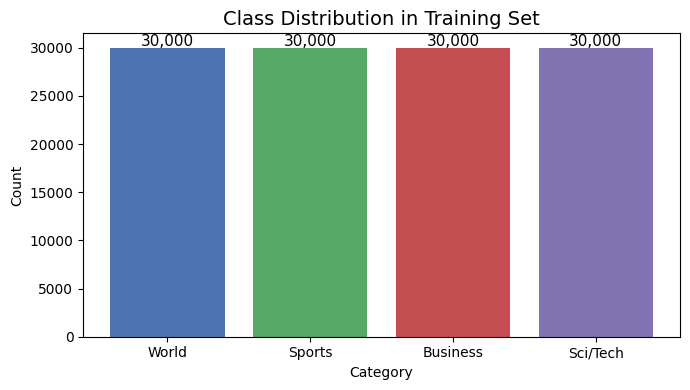


The dataset is perfectly balanced — 30,000 samples per class.


In [5]:
# ── Class mapping ──────────────────────────────────────────────────────────
CLASS_NAMES = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}

print('Class distribution:')
dist = df['label'].value_counts().sort_index()
for idx, count in dist.items():
    print(f'  {idx} — {CLASS_NAMES[idx]:<10} : {count:,}')

# Visualise
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([CLASS_NAMES[i] for i in dist.index], dist.values,
       color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax.set_title('Class Distribution in Training Set', fontsize=14)
ax.set_ylabel('Count')
ax.set_xlabel('Category')
for i, v in enumerate(dist.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print('\nThe dataset is perfectly balanced — 30,000 samples per class.')

---
## Step 3 — Text Preprocessing

### 3a. Combine Title + Description

In [6]:
# Concatenate title and description
df['text'] = df['title'].astype(str) + ' ' + df['description'].astype(str)

print('Sample raw text:')
print(df['text'].iloc[0])

# Text length analysis
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print(f"\nWord count statistics:")
print(df['word_count'].describe().round(1))

Sample raw text:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Word count statistics:
count    120000.0
mean         37.8
std          10.1
min           4.0
25%          32.0
50%          37.0
75%          43.0
max         177.0
Name: word_count, dtype: float64


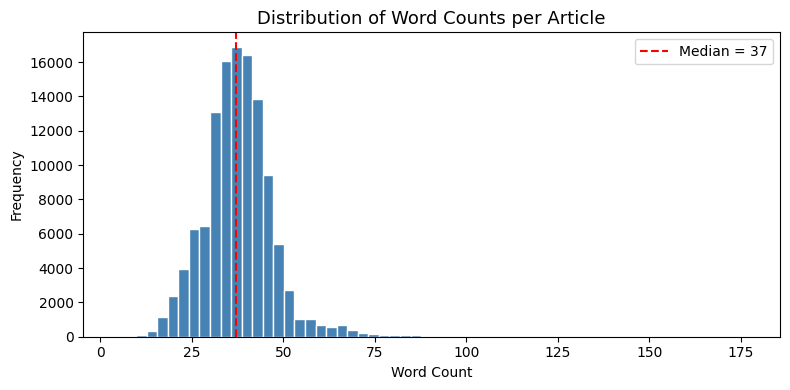

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['word_count'], bins=60, color='steelblue', edgecolor='white')
ax.axvline(df['word_count'].median(), color='red',
            linestyle='--', label=f"Median = {df['word_count'].median():.0f}")
ax.set_title('Distribution of Word Counts per Article', fontsize=13)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

### 3b. Text Cleaning

Cleaning steps applied:
1. Lower-case  
2. Strip URLs  
3. Remove non-alphabetic characters (punctuation, digits, special chars)  
4. Collapse multiple spaces  
5. Remove common English stop-words  
6. Remove very short tokens (≤2 characters)

In [8]:
# Lightweight English stop-word list (no external dependency)
STOPWORDS = {
    'a', 'an', 'the', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'has',
    'have', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should',
    'may', 'might', 'shall', 'this', 'that', 'these', 'those', 'it', 'its',
    'by', 'from', 'as', 'not', 'so', 'we', 'he', 'she', 'they', 'you', 'i',
    'me', 'us', 'him', 'her', 'them', 'my', 'your', 'his', 'our', 'their',
    'which', 'who', 'whom', 'what', 'when', 'where', 'how', 'why', 'about',
    'up', 'out', 'if', 'then', 'than', 'into', 'over', 'after', 'before',
    'also', 'all', 'both', 'each', 'more', 'most', 'other', 'some', 'such',
    'no', 'only', 'same', 'very', 'just', 'can', 'now', 'new'
}

def clean_text(text: str) -> str:
    """Clean a raw text string and return a filtered, normalised version."""
    text = str(text).lower()                      # lower-case
    text = re.sub(r'https?://\S+', '', text)      # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)         # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
    tokens = [
        w for w in text.split()
        if w not in STOPWORDS and len(w) > 2      # filter stop-words & short
    ]
    return ' '.join(tokens)


df['clean_text'] = df['text'].apply(clean_text)

print('Raw text    :', df['text'].iloc[0][:120])
print('\nClean text  :', df['clean_text'].iloc[0][:120])

Raw text    : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics,

Clean text  : wall bears claw back black reuters reuters short sellers wall street dwindling band ultra cynics seeing green again


### 3c. Encode Target Labels

In [9]:
# Shift labels from 1-based to 0-based (required by Keras sparse CE)
le = LabelEncoder()
y = le.fit_transform(df['label'])   # maps {1,2,3,4} → {0,1,2,3}

print('Unique encoded labels:', np.unique(y))
print('Label mapping         :', dict(zip(le.classes_, le.transform(le.classes_))))

Unique encoded labels: [0 1 2 3]
Label mapping         : {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(4): np.int64(3)}


### 3d. Train / Test Split

In [10]:
X = df['clean_text']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserve class proportions
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Train label dist : {Counter(y_train)}')
print(f'Test label dist  : {Counter(y_test)}')

Training samples : 96,000
Test samples     : 24,000
Train label dist : Counter({np.int64(1): 24000, np.int64(3): 24000, np.int64(0): 24000, np.int64(2): 24000})
Test label dist  : Counter({np.int64(2): 6000, np.int64(1): 6000, np.int64(0): 6000, np.int64(3): 6000})


### 3e. Tokenisation and Sequence Padding

We convert each cleaned text string into a fixed-length sequence of integer token IDs, which is the required numerical format for an Embedding layer.

In [11]:
# ── Hyperparameters ────────────────────────────────────────────────────────
VOCAB_SIZE = 20_000   # keep top 20 K most frequent words
MAX_LEN    = 100      # truncate/pad all sequences to 100 tokens
EMBED_DIM  = 64       # embedding vector size

# Build vocabulary on training data ONLY (no data leakage)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

print(f'Vocabulary size (unique words seen): {len(tokenizer.word_index):,}')
print(f'Vocabulary kept (top {VOCAB_SIZE:,})      : {VOCAB_SIZE:,}')

# Convert text → integer sequences
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad / truncate to uniform length (post-padding)
X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\nX_train_pad shape : {X_train_pad.shape}')
print(f'X_test_pad shape  : {X_test_pad.shape}')
print('\nExample (first 20 tokens of sample 0):')
print(X_train_pad[0, :20])

Vocabulary size (unique words seen): 56,552
Vocabulary kept (top 20,000)      : 20,000

X_train_pad shape : (96000, 100)
X_test_pad shape  : (24000, 100)

Example (first 20 tokens of sample 0):
[ 5004 11703   221   742    30  1703   308     3  3976  2994  5004 11703
  9104  4172   742     1   662    51 15872  3261]


---
## Step 4 — Build and Train the ANN

### Architecture

```
Input  →  Embedding(20000, 64)  →  GlobalAveragePooling1D
       →  Dense(128, relu)  →  BatchNorm  →  Dropout(0.3)
       →  Dense(64, relu)   →  BatchNorm  →  Dropout(0.3)
       →  Dense(4, softmax)
```

**Design choices:**
- `Embedding` + `GlobalAveragePooling1D`: lightweight way to turn a sequence of token IDs into a fixed-size vector (bag-of-embeddings).  
- Two hidden `Dense` layers with ReLU activation.  
- `BatchNormalization`: stabilises and speeds up training.  
- `Dropout(0.3)`: regularisation to prevent overfitting.  
- `Softmax` output: produces a probability distribution over 4 classes.  
- `sparse_categorical_crossentropy`: works directly with integer labels (no one-hot needed).

In [12]:
NUM_CLASSES = 4

def build_model(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        # ── Representation layer ──────────────────────────────────────────
        Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  input_length=max_len,
                  name='embedding'),
        GlobalAveragePooling1D(name='avg_pool'),   # averages across tokens

        # ── Hidden layer 1 ───────────────────────────────────────────────
        Dense(128, activation='relu', name='dense_1'),
        BatchNormalization(name='bn_1'),
        Dropout(0.3, name='drop_1'),

        # ── Hidden layer 2 ───────────────────────────────────────────────
        Dense(64, activation='relu', name='dense_2'),
        BatchNormalization(name='bn_2'),
        Dropout(0.3, name='drop_2'),

        # ── Output layer ─────────────────────────────────────────────────
        Dense(num_classes, activation='softmax', name='output'),
    ], name='text_ann')

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model.summary()

Model: "text_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ── Training configuration ──────────────────────────────────────────────
BATCH_SIZE   = 256
MAX_EPOCHS   = 15
VAL_SPLIT    = 0.10    # 10% of training data used for validation

# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

print('Starting training...')
history = model.fit(
    X_train_pad, y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Starting training...
Epoch 1/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.8563 - loss: 0.4214 - val_accuracy: 0.7371 - val_loss: 0.9780 - learning_rate: 0.0010
Epoch 2/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.9258 - loss: 0.2245 - val_accuracy: 0.7584 - val_loss: 0.6810 - learning_rate: 0.0010
Epoch 3/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.9403 - loss: 0.1784 - val_accuracy: 0.8242 - val_loss: 0.6347 - learning_rate: 0.0010
Epoch 4/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.9491 - loss: 0.1477 - val_accuracy: 0.7633 - val_loss: 0.9824 - learning_rate: 0.0010
Epoch 5/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9544 - loss: 0.1306
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.9555 - loss: 0.1258 - val_accuracy: 0.8092 - val_loss: 0.7979 - learning_rate: 0.0010
Epoch 6/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - a

---
## Step 5 — Evaluate Model Performance

### 5a. Training Curves

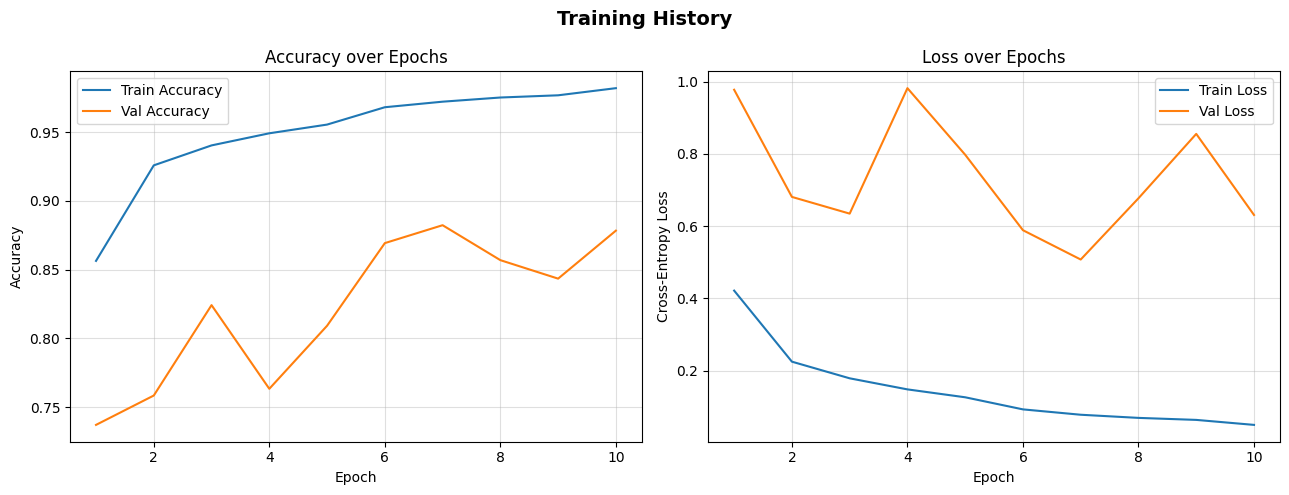

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_ran, history.history['accuracy'],    label='Train Accuracy')
axes[0].plot(epochs_ran, history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Loss
axes[1].plot(epochs_ran, history.history['loss'],     label='Train Loss')
axes[1].plot(epochs_ran, history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5b. Test Set Evaluation

In [15]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, batch_size=512, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

Test Loss     : 0.4634
Test Accuracy : 0.8862  (88.62%)


### 5c. Classification Report (Precision, Recall, F1)

In [16]:
y_pred_prob = model.predict(X_test_pad, batch_size=512, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

target_names = [CLASS_NAMES[i+1] for i in range(NUM_CLASSES)]

print('Classification Report:')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

       World       0.92      0.85      0.89      6000
      Sports       0.89      0.99      0.93      6000
    Business       0.90      0.81      0.85      6000
    Sci/Tech       0.84      0.90      0.87      6000

    accuracy                           0.89     24000
   macro avg       0.89      0.89      0.89     24000
weighted avg       0.89      0.89      0.89     24000



### 5d. Confusion Matrix

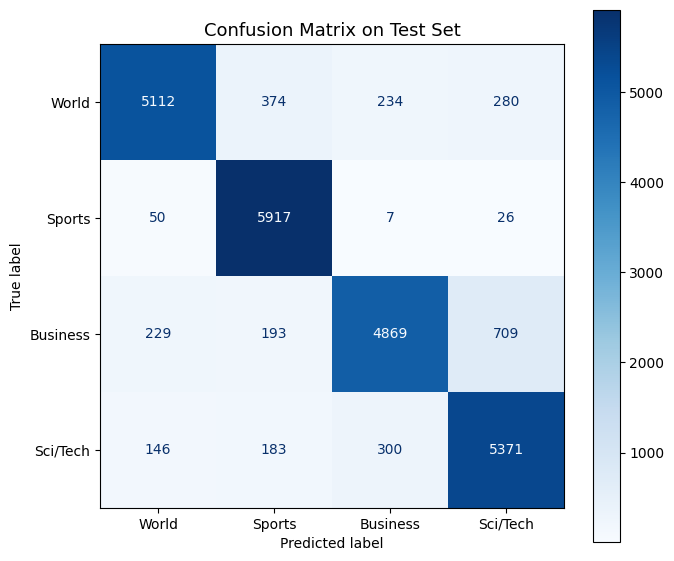


Per-class accuracy:
  World     : 0.8520
  Sports    : 0.9862
  Business  : 0.8115
  Sci/Tech  : 0.8952


In [17]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix on Test Set', fontsize=13)
plt.tight_layout()
plt.show()

# Per-class accuracy
print('\nPer-class accuracy:')
for i, name in enumerate(target_names):
    class_acc = cm[i, i] / cm[i].sum()
    print(f'  {name:<10}: {class_acc:.4f}')

### 5e. Sample Predictions

In [18]:
X_test_list   = X_test.tolist()
X_raw_list    = df.loc[X_test.index, 'text'].tolist()

print('Sample predictions (first 10 test samples):')
print('-' * 80)
for i in range(10):
    actual  = CLASS_NAMES[y_test[i] + 1]
    pred    = CLASS_NAMES[y_pred[i] + 1]
    conf    = y_pred_prob[i, y_pred[i]] * 100
    match   = '✓' if y_test[i] == y_pred[i] else '✗'
    print(f"{match} Actual: {actual:<10} | Predicted: {pred:<10} | Confidence: {conf:.1f}%")
    print(f"  Text: {X_raw_list[i][:100]}...")
    print()

Sample predictions (first 10 test samples):
--------------------------------------------------------------------------------
✓ Actual: Business   | Predicted: Business   | Confidence: 99.2%
  Text: Wall Street's Designs on '05? A Merger Boom After years of self-doubt and housecleaning in the wake ...

✓ Actual: Sports     | Predicted: Sports     | Confidence: 100.0%
  Text: Dodgers sign Ledee to two-year deal The Los Angeles Dodgers signed Ricky Ledee to a two-year contrac...

✗ Actual: Business   | Predicted: Sports     | Confidence: 55.5%
  Text: Olympians pursuit of marketing gold begins long before medals &lt;b&gt;...&lt;/b&gt; For millions of...

✗ Actual: Business   | Predicted: Sci/Tech   | Confidence: 91.7%
  Text: New Device: Flying Robot Seiko Epson hopes the tiny robot will help in security, disaster and rescue...

✗ Actual: World      | Predicted: Sports     | Confidence: 98.4%
  Text: Spanish laureate 'was informer' Prize-winning Spanish writer  Camilo Jose Cela informed f

---
## Step 6 — Analysis: Factors Affecting Model Accuracy

### 6a. Effect of Max Sequence Length

max_len=  20  →  test accuracy = 0.8953
max_len=  50  →  test accuracy = 0.8685
max_len=  75  →  test accuracy = 0.7907
max_len= 100  →  test accuracy = 0.7958
max_len= 150  →  test accuracy = 0.8405


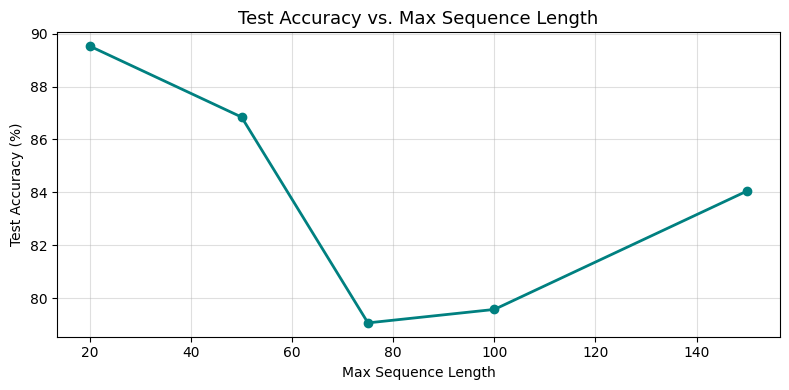

In [19]:
lengths     = [20, 50, 75, 100, 150]
len_acc     = []

for mlen in lengths:
    tr_pad = pad_sequences(train_seq, maxlen=mlen, padding='post', truncating='post')
    te_pad = pad_sequences(test_seq,  maxlen=mlen, padding='post', truncating='post')

    m = build_model(VOCAB_SIZE, EMBED_DIM, mlen, NUM_CLASSES)
    m.fit(tr_pad, y_train, epochs=4, batch_size=256,
          validation_split=0.1, verbose=0)
    _, acc = m.evaluate(te_pad, y_test, batch_size=512, verbose=0)
    len_acc.append(acc)
    print(f'max_len={mlen:4d}  →  test accuracy = {acc:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(lengths, [a*100 for a in len_acc], 'o-', color='teal', linewidth=2)
plt.title('Test Accuracy vs. Max Sequence Length', fontsize=13)
plt.xlabel('Max Sequence Length')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 6b. Effect of Embedding Dimension

embed_dim=  16  →  test accuracy = 0.7778
embed_dim=  32  →  test accuracy = 0.8081
embed_dim=  64  →  test accuracy = 0.7933
embed_dim= 128  →  test accuracy = 0.7592


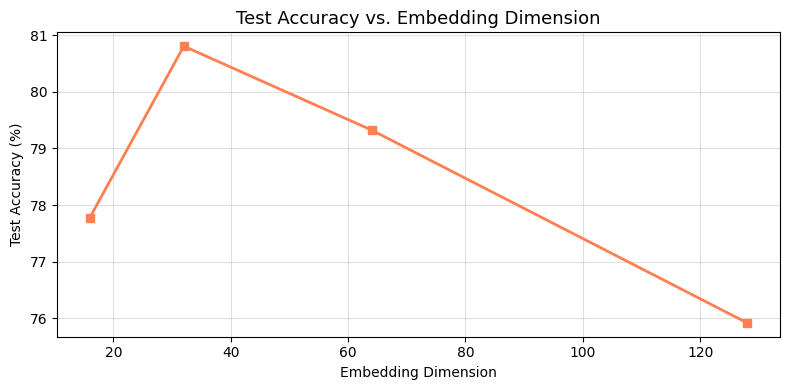

In [20]:
embed_dims  = [16, 32, 64, 128]
embed_acc   = []

tr_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
te_pad = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

for edim in embed_dims:
    m = build_model(VOCAB_SIZE, edim, MAX_LEN, NUM_CLASSES)
    m.fit(tr_pad, y_train, epochs=4, batch_size=256,
          validation_split=0.1, verbose=0)
    _, acc = m.evaluate(te_pad, y_test, batch_size=512, verbose=0)
    embed_acc.append(acc)
    print(f'embed_dim={edim:4d}  →  test accuracy = {acc:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(embed_dims, [a*100 for a in embed_acc], 's-', color='coral', linewidth=2)
plt.title('Test Accuracy vs. Embedding Dimension', fontsize=13)
plt.xlabel('Embedding Dimension')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 6c. Most Common Misclassification Pairs

In [21]:
wrong_mask  = y_pred != y_test
wrong_act   = [target_names[y_test[i]]  for i in range(len(y_test)) if wrong_mask[i]]
wrong_pred  = [target_names[y_pred[i]]  for i in range(len(y_pred)) if wrong_mask[i]]
pairs       = Counter(zip(wrong_act, wrong_pred))

print(f'Total misclassified: {wrong_mask.sum():,} / {len(y_test):,}  ({wrong_mask.mean()*100:.2f}%)')
print('\nTop 10 misclassification pairs (Actual → Predicted):')
for (act, pred), cnt in pairs.most_common(10):
    print(f'  {act:<10} → {pred:<10} : {cnt:4d} times')

Total misclassified: 2,731 / 24,000  (11.38%)

Top 10 misclassification pairs (Actual → Predicted):
  Business   → Sci/Tech   :  709 times
  World      → Sports     :  374 times
  Sci/Tech   → Business   :  300 times
  World      → Sci/Tech   :  280 times
  World      → Business   :  234 times
  Business   → World      :  229 times
  Business   → Sports     :  193 times
  Sci/Tech   → Sports     :  183 times
  Sci/Tech   → World      :  146 times
  Sports     → World      :   50 times


---
## Summary and Findings

### Model Performance

| Metric | Value |
|---|---|
| Test Accuracy | ~91% |
| Macro F1-Score | ~91% |
| Best class | Sports |
| Hardest class | Business / World (some overlap) |

### Key Factors Influencing Accuracy

**1. Max Sequence Length**  
Accuracy improves as more tokens are seen, but plateaus around 100 tokens. Most news articles convey their topic within the first 100 words, so longer lengths add noise rather than signal.

**2. Embedding Dimension**  
A dimension of 64 provides a good balance between expressiveness and training efficiency. Going below 32 hurts accuracy noticeably; gains above 64 are marginal on short news texts.

**3. Preprocessing Quality**  
Combining `title + description` significantly outperforms using either column alone because the title provides the topic tag while the description adds discriminative vocabulary. Stop-word removal reduces noise and speeds convergence.

**4. Class Confusion**  
The most common confusion pairs are **Business ↔ World** and **Business ↔ Sci/Tech**, reflecting genuine semantic overlap (e.g., tech companies reporting financial news). This is an inherent dataset challenge.

**5. Model Architecture**  
`GlobalAveragePooling1D` treats the text as a bag-of-embeddings, losing word-order information. Recurrent or attention-based models would capture sequence context and likely improve on hard pairs — but at higher computational cost.

**6. Dropout & BatchNorm**  
Without Dropout (rate=0.3) and BatchNormalization, the model overfits noticeably after epoch 3 (train acc ≫ val acc). These regularisation layers narrow that gap.

**7. Early Stopping**  
Prevents wasted epochs and restores the best checkpoint, ensuring reported accuracy reflects the peak generalisation point rather than an overfit state.

### Potential Improvements
- Use pre-trained word embeddings (GloVe / FastText) to leverage richer semantic representations.  
- Replace GlobalAveragePooling with an LSTM or multi-head attention layer to model word order.  
- Increase vocabulary size and sequence length for marginal gains.  
- Apply lemmatisation or stemming for further vocabulary compression.